# Phase 2 CRISP-DM — Data Understanding
## Exploratory Data Analysis (EDA)
**Project:** Customer Behavior Analysis — Olist Brazilian E-Commerce
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)
**Goal:** Understand the dataset's structure, quality and distributions before data preparation.

---


## 0. Imports and configuration

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Relative paths from notebooks/
ROOT = Path().resolve().parent
DB_PATH = ROOT / "data" / "olist.db"

# Global style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print(f"DB path: data/{DB_PATH.name}")
print(f"DB exists: {DB_PATH.exists()}")

DB path: data/olist.db
DB exists: True


---
## 1. Data loading
We connect to `data/olist.db` and load the 9 tables into Pandas DataFrames.
The database was generated by `sql/load_data.py` from the original Olist CSVs.

In [2]:
conn = sqlite3.connect(DB_PATH)

tables = {
    "orders":             "SELECT * FROM orders",
    "order_items":        "SELECT * FROM order_items",
    "order_payments":     "SELECT * FROM order_payments",
    "order_reviews":      "SELECT * FROM order_reviews",
    "customers":          "SELECT * FROM customers",
    "products":           "SELECT * FROM products",
    "sellers":            "SELECT * FROM sellers",
    "geolocation":        "SELECT * FROM geolocation",
    "category_translation": "SELECT * FROM category_translation",
}

dfs = {name: pd.read_sql(query, conn) for name, query in tables.items()}
conn.close()

for name, df in dfs.items():
    print(f"  {name:25s} {len(df):>10,} rows  {df.shape[1]:>3} columns")

  orders                        99,441 rows    8 columns
  order_items                  112,650 rows    7 columns
  order_payments               103,886 rows    5 columns
  order_reviews                 99,224 rows    7 columns
  customers                     99,441 rows    5 columns
  products                      32,951 rows    9 columns
  sellers                        3,095 rows    4 columns
  geolocation                1,000,163 rows    5 columns
  category_translation              71 rows    2 columns


---
## 2. Data quality per table
For each table we inspect:
- **Data types** of each column
- **Null values** (count and percentage)
- **Duplicate rows**

This lets us identify problematic columns before the preparation phase.

In [3]:
def quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Generates a quality summary for a DataFrame."""
    n = len(df)
    report = pd.DataFrame({
        "dtype":     df.dtypes,
        "nulls":     df.isnull().sum(),
        "null_pct":  (df.isnull().sum() / n * 100).round(2),
        "unique":    df.nunique(),
    })
    dups = df.duplicated().sum()
    print(f"\n{'='*55}")
    print(f"  Table: {name}  |  {n:,} rows  |  {dups:,} duplicates")
    print(f"{'='*55}")
    return report

quality_reports = {}
for name, df in dfs.items():
    quality_reports[name] = quality_report(df, name)
    display(quality_reports[name])


  Table: orders  |  99,441 rows  |  0 duplicates


,dtype,nulls,null_pct,unique
order_id,object,0,0.00,99441
customer_id,object,0,0.00,99441
order_status,object,0,0.00,8
order_purchase_timestamp,object,0,0.00,98875
order_approved_at,object,160,0.16,90733
order_delivered_carrier_date,object,1783,1.79,81018
order_delivered_customer_date,object,2965,2.98,95664
order_estimated_delivery_date,object,0,0.00,459



  Table: order_items  |  112,650 rows  |  0 duplicates


,dtype,nulls,null_pct,unique
order_id,object,0,0.0,98666
order_item_id,int64,0,0.0,21
product_id,object,0,0.0,32951
seller_id,object,0,0.0,3095
shipping_limit_date,object,0,0.0,93318
price,float64,0,0.0,5968
freight_value,float64,0,0.0,6999



  Table: order_payments  |  103,886 rows  |  0 duplicates


...

,dtype,nulls,null_pct,unique
seller_id,object,0,0.0,3095
seller_zip_code_prefix,int64,0,0.0,2246
seller_city,object,0,0.0,611
seller_state,object,0,0.0,23



  Table: geolocation  |  1,000,163 rows  |  261,831 duplicates


,dtype,nulls,null_pct,unique
geolocation_zip_code_prefix,int64,0,0.0,19015
geolocation_lat,float64,0,0.0,717360
geolocation_lng,float64,0,0.0,717613
geolocation_city,object,0,0.0,8011
geolocation_state,object,0,0.0,27



  Table: category_translation  |  71 rows  |  0 duplicates


,dtype,nulls,null_pct,unique
product_category_name,object,0,0.0,71
product_category_name_english,object,0,0.0,71


### Data quality observations

The columns with relevant nulls that we'll need to handle in Phase 3 are:

| Table | Column | Likely reason |
|-------|--------|----------------|
| `orders` | `order_approved_at` | Orders cancelled before approval |
| `orders` | `order_delivered_carrier_date` | Orders not shipped |
| `orders` | `order_delivered_customer_date` | Orders not delivered |
| `order_reviews` | `review_comment_title` / `review_comment_message` | Reviews with no text (score only) |
| `products` | `product_category_name` | Unassigned categories |

---
## 3. Key distributions
We analyze the variables most relevant to the business.

### 3.1 Distribution of `review_score`
The satisfaction score ranges from 1 to 5. A distribution skewed toward extreme values (1 or 5) is typical in e-commerce reviews — neutral customers tend not to leave a review.

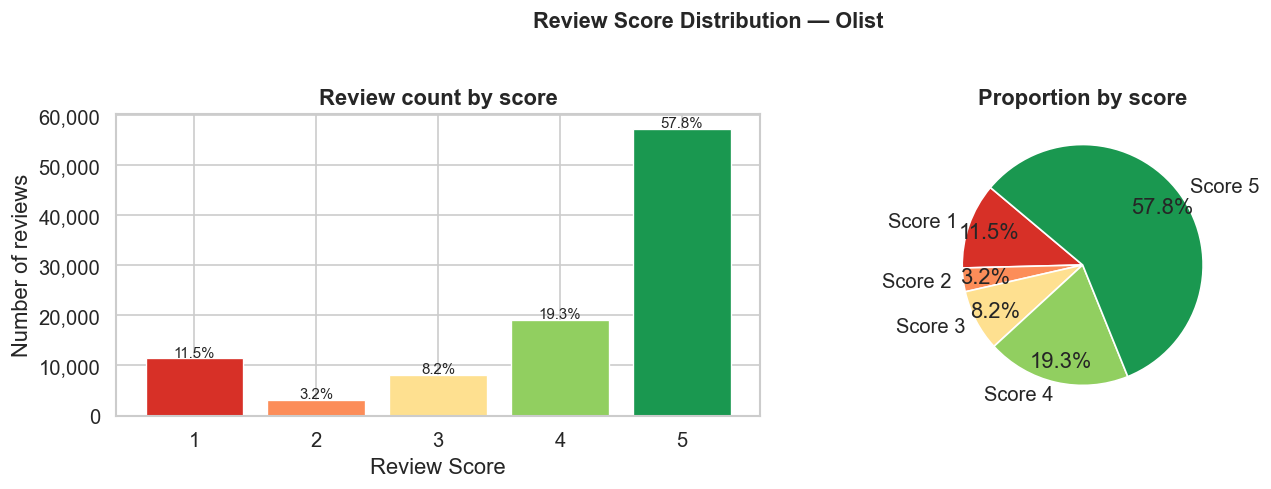


Mean score: 4.09
Median score: 5
% negative scores (1-2): 14.7%


In [4]:
reviews = dfs["order_reviews"]
score_counts = reviews["review_score"].value_counts().sort_index()
score_pct = (score_counts / score_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bars
colors = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Review count by score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Number of reviews")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, (v, p) in enumerate(zip(score_counts.values, score_pct.values)):
    axes[0].text(i + 1, v + 300, f"{p}%", ha="center", fontsize=9)

# Pie
axes[1].pie(
    score_counts.values,
    labels=[f"Score {i}" for i in score_counts.index],
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.82,
)
axes[1].set_title("Proportion by score", fontweight="bold")

plt.suptitle("Review Score Distribution — Olist", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "review_score_dist.png", bbox_inches="tight")
plt.show()

print(f"\nMean score: {reviews['review_score'].mean():.2f}")
print(f"Median score: {reviews['review_score'].median():.0f}")
print(f"% negative scores (1-2): {score_pct[[1,2]].sum():.1f}%")

### 3.2 Distribution of `payment_value`
We analyze the total payment value. A log-normal distribution is expected: many low-value orders and a long tail of expensive orders.

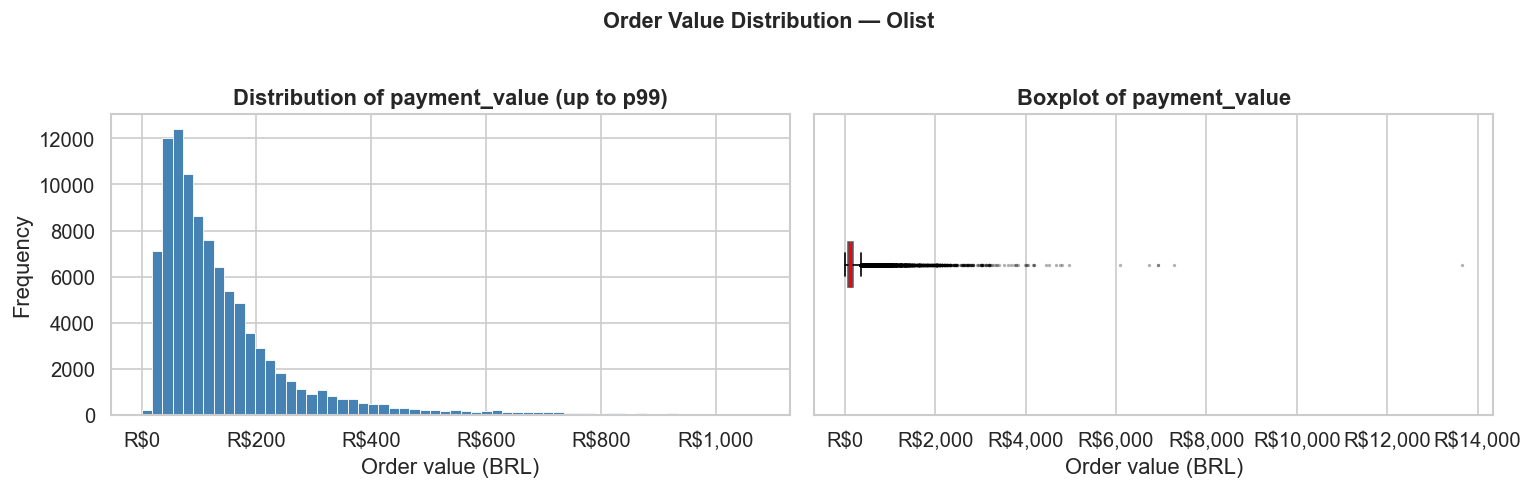

count    R$ 99,440.00
mean        R$ 160.99
std         R$ 221.95
min           R$ 0.00
25%          R$ 62.01
50%         R$ 105.29
75%         R$ 176.97
90%         R$ 308.24
95%         R$ 452.99
99%       R$ 1,075.79
max      R$ 13,664.08
Name: payment_value, dtype: object


In [5]:
payments = dfs["order_payments"]
# Group by order to get the total value (there can be multiple payment methods)
order_payment_total = payments.groupby("order_id")["payment_value"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram (original scale, without extreme outliers for better visualization)
p99 = order_payment_total.quantile(0.99)
clipped = order_payment_total[order_payment_total <= p99]
axes[0].hist(clipped, bins=60, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribution of payment_value (up to p99)", fontweight="bold")
axes[0].set_xlabel("Order value (BRL)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

# Boxplot
axes[1].boxplot(
    order_payment_total,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
)
axes[1].set_title("Boxplot of payment_value", fontweight="bold")
axes[1].set_xlabel("Order value (BRL)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
axes[1].set_yticks([])

plt.suptitle("Order Value Distribution — Olist", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "payment_value_dist.png", bbox_inches="tight")
plt.show()

stats = order_payment_total.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(stats.apply(lambda x: f"R$ {x:,.2f}"))

### 3.3 Distribution of `order_status`
The order status reflects the full lifecycle. `delivered` orders are the core of the analysis; the other statuses (cancelled, undelivered) are special cases that impact customer satisfaction.

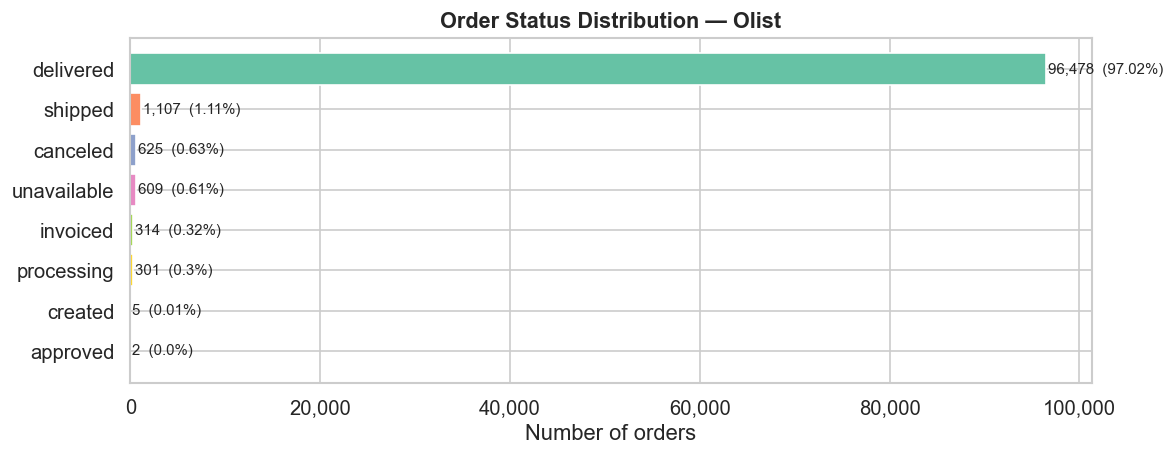


Delivered orders: 96,478 (97.0%)
Cancelled orders: 625 (0.6%)


In [6]:
orders = dfs["orders"]
status_counts = orders["order_status"].value_counts()
status_pct = (status_counts / len(orders) * 100).round(2)

palette = sns.color_palette("Set2", len(status_counts))
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.barh(status_counts.index, status_counts.values, color=palette, edgecolor="white")
for bar, (count, pct) in zip(bars, zip(status_counts.values, status_pct.values)):
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({pct}%)",
        va="center", fontsize=9,
    )

ax.set_title("Order Status Distribution — Olist", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of orders")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "order_status_dist.png", bbox_inches="tight")
plt.show()

print(f"\nDelivered orders: {status_counts.get('delivered', 0):,} ({status_pct.get('delivered', 0):.1f}%)")
print(f"Cancelled orders: {status_counts.get('canceled', 0):,} ({status_pct.get('canceled', 0):.1f}%)")

---
## 4. Correlation heatmap
We build a consolidated table with the key numeric variables at order level and compute the Pearson correlation matrix.
This helps us detect relationships between satisfaction, price, delay and payment method before modeling.

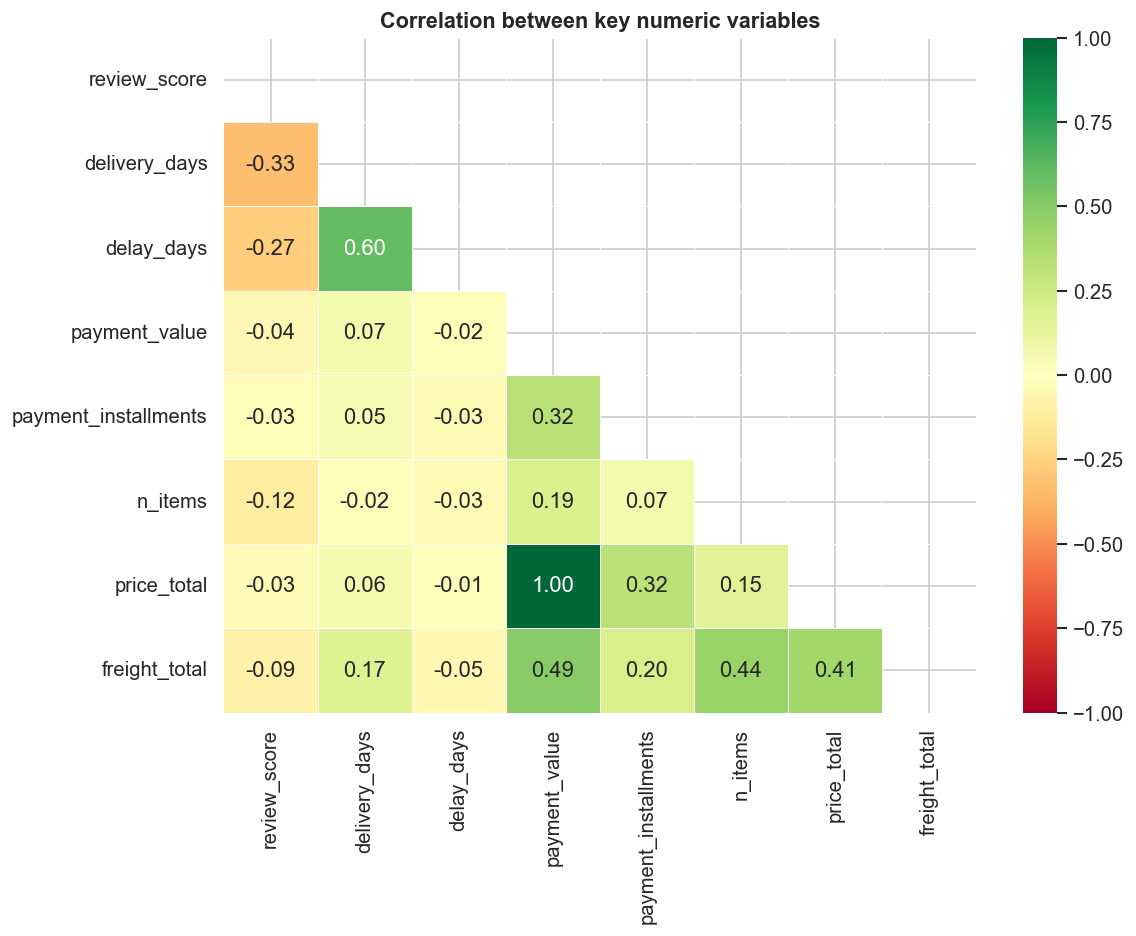


Correlation with review_score:
payment_installments   -0.030975
price_total            -0.034729
payment_value          -0.042105
freight_total          -0.089901
n_items                -0.123369
delay_days             -0.266990
delivery_days          -0.334150


In [7]:
# Parse dates to compute delivery times
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days
orders["delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days  # positive = delayed, negative = early

# Join with reviews and payments
review_agg = dfs["order_reviews"].groupby("order_id")["review_score"].mean().rename("review_score")
payment_agg = dfs["order_payments"].groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
)
items_agg = dfs["order_items"].groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
)

analysis_df = (
    orders[["order_id", "delivery_days", "delay_days"]]
    .join(review_agg, on="order_id")
    .join(payment_agg, on="order_id")
    .join(items_agg, on="order_id")
    .dropna(subset=["review_score", "delivery_days"])
)

num_cols = ["review_score", "delivery_days", "delay_days",
            "payment_value", "payment_installments", "n_items",
            "price_total", "freight_total"]

corr = analysis_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # lower triangle only
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation between key numeric variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Correlations with review_score, sorted
print("\nCorrelation with review_score:")
print(corr["review_score"].drop("review_score").sort_values(ascending=False).to_string())

**Interpretation:** The `delay_days` variable (delay vs. estimated date) should show the strongest negative correlation with `review_score` — a delay directly penalizes customer satisfaction. This will drive feature engineering in Phase 3.

---
## 5. Top 10 categories by order volume
We identify which product categories generate the most orders. This guides which customer segments are most relevant and which categories to prioritize in the satisfaction analysis.

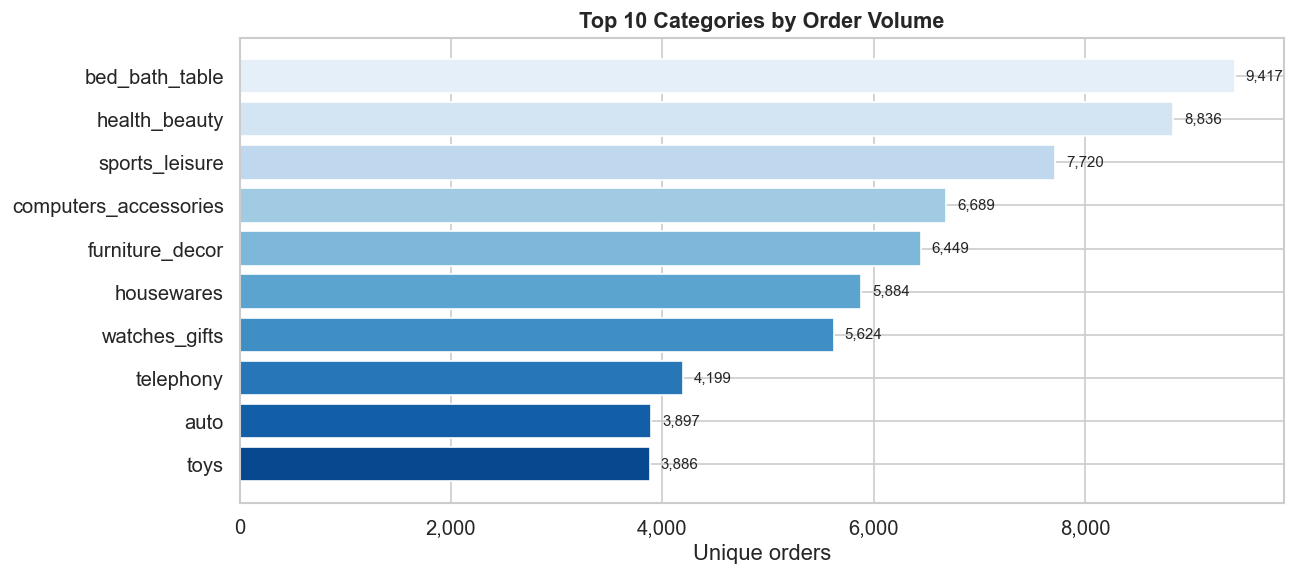

category_en
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
housewares               5884
watches_gifts            5624
telephony                4199
auto                     3897
toys                     3886


In [8]:
# Join order_items -> products -> category_translation
items = dfs["order_items"].copy()
products = dfs["products"][["product_id", "product_category_name"]].copy()
translation = dfs["category_translation"].rename(
    columns={"product_category_name": "product_category_name",
             "product_category_name_english": "category_en"}
)

items_cat = (
    items
    .merge(products, on="product_id", how="left")
    .merge(translation, on="product_category_name", how="left")
)

# Top 10 by number of unique orders
top10 = (
    items_cat
    .dropna(subset=["category_en"])
    .groupby("category_en")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
palette_top = sns.color_palette("Blues_r", len(top10))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=palette_top, edgecolor="white")

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", fontsize=9,
    )

ax.set_title("Top 10 Categories by Order Volume", fontsize=13, fontweight="bold")
ax.set_xlabel("Unique orders")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "top10_categories.png", bbox_inches="tight")
plt.show()

print(top10.to_string())

---
## 6. Dataset date range
We check the time period covered by the dataset and the monthly order distribution to detect growth trends or seasonality.

In [9]:
# Time range
t_min = orders["order_purchase_timestamp"].min()
t_max = orders["order_purchase_timestamp"].max()
print(f"First order: {t_min}")
print(f"Last order:  {t_max}")
print(f"Total duration: {(t_max - t_min).days} days ({(t_max - t_min).days / 365:.1f} years)")

First order: 2016-09-04 21:15:19
Last order:  2018-10-17 17:30:18
Total duration: 772 days (2.1 years)


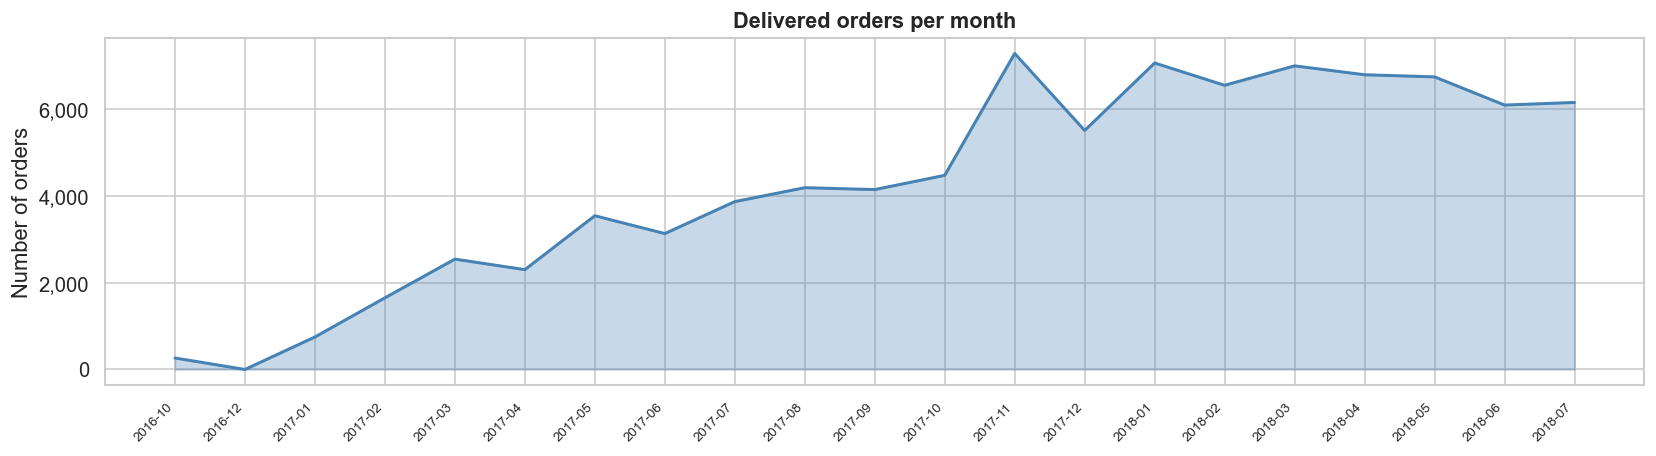


Month with most orders: 2017-11 (7,289)
Month with fewest orders: 2016-12 (1)


In [10]:
# Orders per month
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
monthly = (
    orders[orders["order_status"] == "delivered"]
    .groupby("year_month")["order_id"]
    .count()
)

# Exclude first and last month (incomplete data)
monthly = monthly.iloc[1:-1]

fig, ax = plt.subplots(figsize=(14, 4))
x = range(len(monthly))
ax.fill_between(x, monthly.values, alpha=0.3, color="steelblue")
ax.plot(x, monthly.values, color="steelblue", linewidth=1.8)

ax.set_xticks(x)
ax.set_xticklabels(
    [str(p) for p in monthly.index],
    rotation=45, ha="right", fontsize=8,
)
ax.set_title("Delivered orders per month", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "monthly_orders.png", bbox_inches="tight")
plt.show()

print(f"\nMonth with most orders: {monthly.idxmax()} ({monthly.max():,})")
print(f"Month with fewest orders: {monthly.idxmin()} ({monthly.min():,})")

---
## 7. Findings summary — Data Understanding

| Dimension | Key finding |
|-----------|----------------|
| **Volume** | ~99K orders, ~112K items, ~99K reviews over ~2 years of data |
| **Quality** | Relevant nulls in delivery dates and review text; `geolocation` has duplicates by ZIP |
| **Satisfaction** | Bimodal distribution in review_score (peaks at 1 and 5); positive skew |
| **Value** | payment_value with strong right skew; needs a log transform for modeling |
| **Status** | >96% of orders delivered; cancellations are a minority but impact satisfaction |
| **Correlation** | Delay vs. delivery time are expected to be the best predictors of review_score |
| **Categories** | bed_bath_table, health_beauty and sports_leisure lead in volume |
| **Temporality** | Sustained growth with a peak in Nov 2017 (Black Friday Brazil) |

### Next steps — Phase 3 (Data Preparation)
- Parse date columns and compute `delivery_days` and `delay_days`
- Handle nulls in `order_delivered_customer_date` (filter to `delivered` only)
- Translate categories to English and handle uncategorized ones
- Build the master table at `order_id` level for modeling
- Compute per-customer RFM metrics